# Chicago Risk District Classification
In this notebook we continue the exploration on `df_crime`, but now focused on time and spatial analysis. Since our main goal is unsupervised learning, clustering Chicago districts by risk profiles, we structure our EDA around a central question: **Which variables best characterize differences between districts, and are those differences stable and meaningful enough to support clustering?** Unlike predictive modeling, where the focus is on the relationship with a target variable, EDA for clustering focuses on separation and similarity.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt
from statsmodels.tsa.seasonal import STL
import geopandas as gpd
from shapely.geometry import shape, Point
import contextily as ctx
from libpysal.weights import Queen
from esda import Moran, Moran_Local
from splot.esda import lisa_cluster, moran_scatterplot
from json import loads
from sklearn.preprocessing import StandardScaler

In [2]:
from sys import path

path.insert(0, '../modules')

import utils as f
import params_cfg as pc
import visuals

colors = pc.COLORS
gen_theft = pc.GENERAL_THFT
gen_aslt = pc.GENERAL_ASLT
census_data = pc.CENSUS_DATA

%load_ext autoreload
%autoreload 2

In [3]:
# defining the project paths
brz_path = pc.BRZ_PATH
slv_path = pc.SLV_PATH
gld_path = pc.GLD_PATH
img_path = pc.IMG_PATH
model_path = pc.MODEL_PATH

In [4]:
df_crime = pd.read_csv(
    f'{slv_path}/df_crime_final.csv',
    index_col='date',
    parse_dates=True
)

df_crime['id'] = df_crime['id'].astype(str)
df_crime['district'] = df_crime['district'].astype(str)
df_crime['ddate'] = pd.to_datetime(df_crime.index.date)

df_crime = df_crime.loc[:'2025'].copy()

df_crime.head()

,id,arrest,domestic,district,community_area,crime_lat,crime_lon,crime_group,crime_distance,min_dist_station,...,avg_per_capita_income,avg_hardship_index,pct_housing_crowded,pct_hh_below_pvty,pct_16_unemployed,pct_25_without_hsd,pct_dependents,per_capita_income,hardship_index,ddate
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:03:00,12581802,0,0,10,29,41.863540,-87.728763,ASLT,1.852004,1.852004,...,20979.833333,63.166667,0.074,0.431,0.212,0.276,0.427,12034.0,87,2022-01-01
2022-01-01 00:04:00,12582232,0,0,12,28,41.884630,-87.670621,ASLT,2.659790,2.659790,...,38318.700000,40.500000,0.038,0.206,0.107,0.096,0.222,44689.0,15,2022-01-01
2022-01-01 00:05:00,12582704,0,0,9,61,41.813152,-87.669950,ASLT,3.327426,3.327426,...,19866.333333,69.466667,0.119,0.290,0.230,0.415,0.389,12765.0,91,2022-01-01
2022-01-01 00:05:00,12581815,0,0,11,26,41.883342,-87.727544,ASLT,2.124182,2.124182,...,21936.285714,63.571429,0.094,0.417,0.258,0.245,0.436,10934.0,92,2022-01-01
2022-01-01 00:05:00,12582341,0,0,4,48,41.734336,-87.580512,ASLT,3.104587,3.104587,...,18437.833333,61.333333,0.021,0.115,0.200,0.110,0.440,28887.0,38,2022-01-01


## Time Analysis
This section aims to characterize the temporal behavior of crime activity in Chicago. Understanding trends, seasonality, and variability is fundamental for constructing representative features and identifying persistent or transient patterns across districts.

### Daily Count
We start by exploring time tendencies, to check whether ASLT and THFT occurrences are increasing, are stable, or even if seasonality is involved. Daily counts provide a first overview of crime activity over time. They allow the identification of spikes, abrupt changes, and general patterns in the occurrence of events throughout the study period.

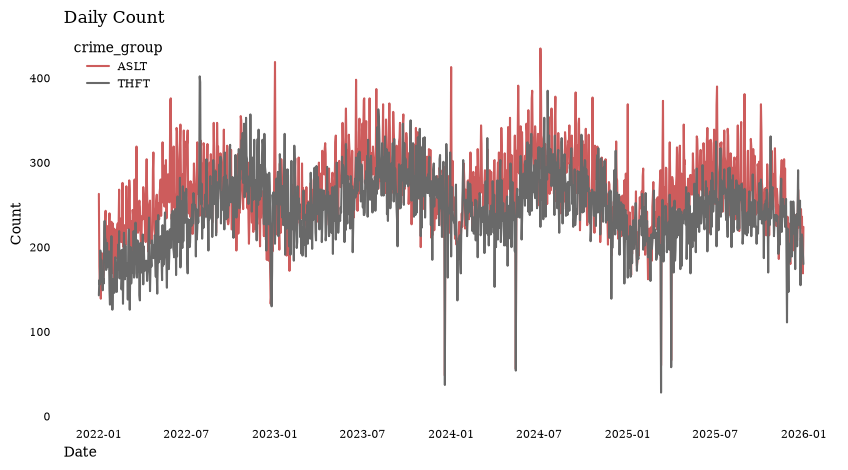

In [5]:
grp = df_crime[['ddate', 'crime_group', 'id']]\
    .groupby(['ddate', 'crime_group'])\
    .count()\
    .reset_index()

sns.lineplot(
    data=grp,
    x='ddate',
    y='id',
    hue='crime_group',
    palette=colors
)

plt.ylim(0)
plt.title('Daily Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Date', loc='left')
plt.box(False);

### Moving Average
However, daily crime counts are inherently noisy. Rolling averages smooth short-term fluctuations and highlight underlying trends, making long-term changes and seasonal effects easier to visualize.

In particular, we observe that ASLT and THFT move together and a seasonal effect is present.

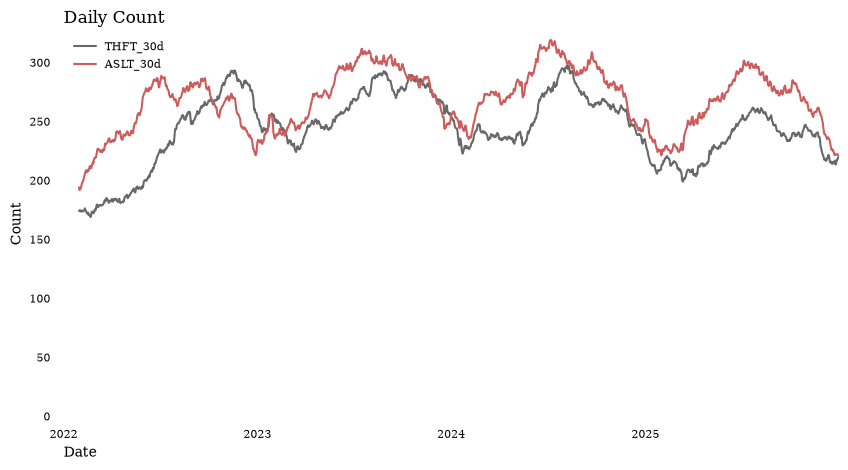

In [6]:
grp = df_crime[['ddate', 'crime_group', 'id']]\
    .groupby(['ddate', 'crime_group'])\
    .count()\
    .reset_index()


grp_aslt = grp.query('crime_group == "ASLT"').copy()
grp_thft = grp.query('crime_group == "THFT"').copy()

k = 30
grp_aslt[f'ASLT_{k}d'] = grp_aslt['id'].rolling(k).mean()
grp_thft[f'THFT_{k}d'] = grp_thft['id'].rolling(k).mean()

grp_ma = grp_thft[['ddate', f'THFT_{k}d']].merge(
    grp_aslt[['ddate', f'ASLT_{k}d']],
    how='inner',
    on='ddate'
)

grp_ma.plot(
    x='ddate',
    color=list(colors.values())
)

plt.ylim(0)
plt.title('Daily Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Date', loc='left')
plt.box(False);

### Monthly and Weekday Counts
Aggregating crimes by month and weekday enables the investigation of seasonal and weekly patterns, helping in idenfifying periods of increased activity and recurring temporal behaviors. As such, we notice mid-year to be the period with most occurrences for ASLT. The same can be said about Sunday.

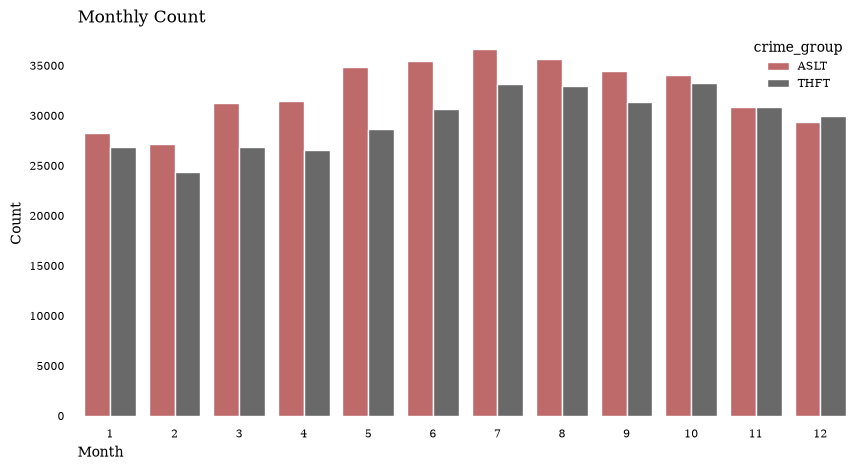

In [7]:
df_crime['mdate'] = df_crime['ddate'].dt.month

grp = df_crime[['mdate', 'crime_group', 'id']]\
    .groupby(['mdate', 'crime_group'])\
    .count()\
    .reset_index()


sns.barplot(
    data=grp,
    x='mdate',
    y='id',
    hue='crime_group',
    palette=colors
)

plt.title('Monthly Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Month', loc='left')
plt.box(False);

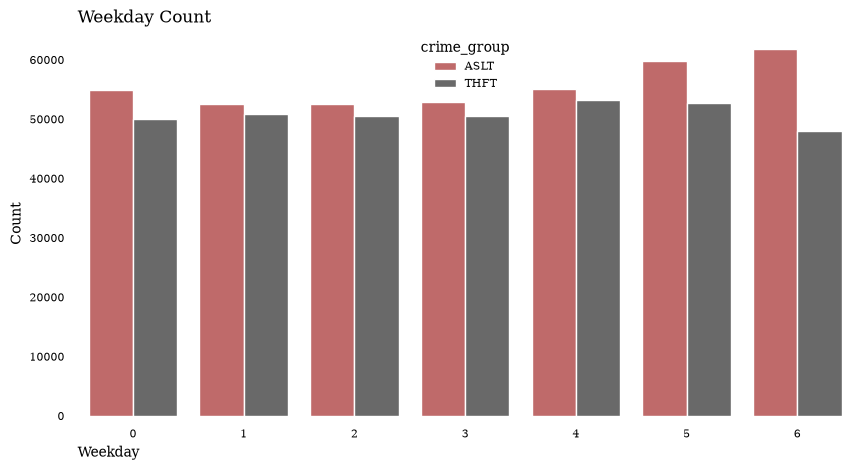

In [8]:
df_crime['weekday'] = df_crime['ddate'].dt.weekday

grp = df_crime[['weekday', 'crime_group', 'id']]\
    .groupby(['weekday', 'crime_group'])\
    .count()\
    .reset_index()


sns.barplot(
    data=grp,
    x='weekday',
    y='id',
    hue='crime_group',
    palette=colors
)

plt.title('Weekday Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Weekday', loc='left')
plt.box(False);

### Aggregation per District
District-level summary statistics quantify differences in crime intensity and variability among districts. While the mean represents the average level of activity, the standard deviation and coefficient of variation measure the stability and volatility of crime occurrences over time. We will use the mean value to plot a choropleth map of Chicago districts later.

In [9]:
grp_daily = df_crime[['ddate', 'district', 'crime_group', 'id']]\
    .groupby(['ddate', 'district', 'crime_group'])\
    .count()\
    .reset_index()

grp_dst = grp_daily\
    .groupby(['district', 'crime_group'])\
    .agg(
        mean=('id', 'mean'),
        std=('id', 'std')
    )\
    .reset_index()

grp_dst['cv'] = grp_dst['std'] / grp_dst['mean']
grp_dst.sort_values('mean', ascending=False).head(10)

,district,crime_group,mean,std,cv
4,11,ASLT,19.974675,5.362992,0.268490
17,18,THFT,18.484600,6.055050,0.327573
1,1,THFT,18.252740,7.439302,0.407572
36,6,ASLT,18.062971,5.070071,0.280689
7,12,THFT,18.017796,5.762630,0.319830
19,19,THFT,17.875342,6.164265,0.344847
40,8,ASLT,17.242984,5.053870,0.293097
32,4,ASLT,16.524983,4.846573,0.293288
30,3,ASLT,15.574949,4.550857,0.292191
41,8,THFT,14.815195,4.925757,0.332480


### Time Series Decomposition
Time series decomposition separates the observed signal into interpretable components, allowing a better understanding of the mechanisms driving crime dynamics. It is composed of:

- Trend: captures long-term changes in crime activity, revealing whether the number of occurences is increasing, decreasing, or remaining stable over the years
- Seasonality: represents periodic fluctuations. These recurring patterns may be associated with weather conditions, holidays, or other cyclical factors influencing criminal behavior.

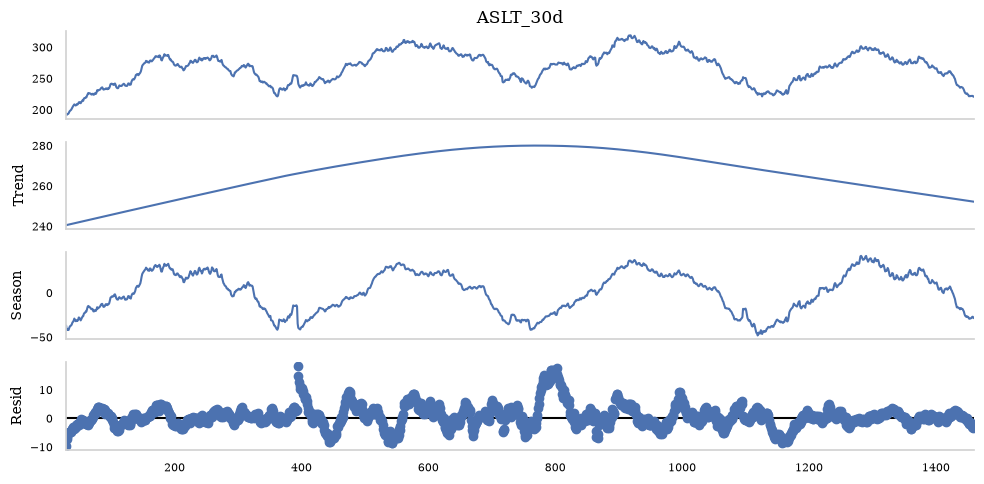

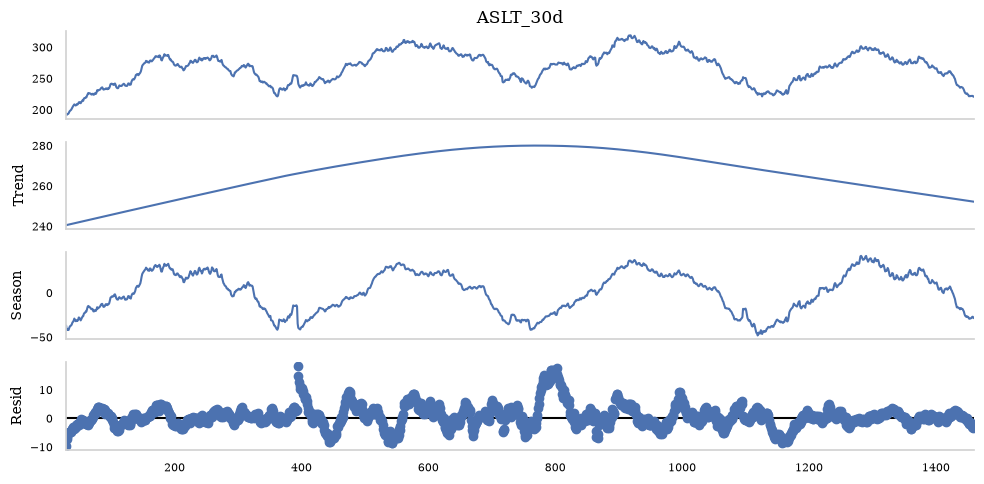

In [11]:
stl = STL(grp_ma['ASLT_30d'].dropna(), period=365)
res = stl.fit()
res.plot()

## Spatial Analysis
This section investigates the geographical distribution of crime and socioeconomic indicators across Chicago districts. Spatial analysis provides insights into the presence of hotspots and evaluates whether neighboring districts exhibits similar characteristics.

We thus start by filtering ASLT in `df_crime` and grouping the resulting dataframe by district, collecting arrest and domestic rates, and the average hardship.

In [12]:
grp_dist = df_crime.query('crime_group == "ASLT"')[[
    'district', 'id', 'arrest',
    'domestic', 'hardship_index'
]].groupby('district')\
    .agg(
        count=('id', 'count'),
        arrest_rate=('arrest', 'mean'),
        domestic_rate=('domestic', 'mean'),
        avg_hardship=('hardship_index', 'mean')
    )
grp_dist.head()

,count,arrest_rate,domestic_rate,avg_hardship
district,,,,
1,16856,0.272010,0.135204,9.159824
10,20714,0.289707,0.320460,89.539876
11,29183,0.374773,0.288284,83.896789
12,19408,0.161531,0.218467,30.115004
14,9977,0.190638,0.237446,27.438909


In order to plot the choropleth map, we need the geometry information in the `df_districts` dataframe.

In [13]:
df_districts = pd.read_csv(f'{slv_path}/df_districts.csv')
df_districts['district'] = df_districts['district'].astype(int).astype(str)

# converting the geometry column to shapely objects
# by first replacing single quotes with double quotes in order to
# avoid json parsing errors 
df_districts['the_geom'] = df_districts['the_geom']\
    .str.replace("'", '"')\
    .apply(loads)

gdf_districts = df_districts.copy()
gdf_districts['geometry'] = gdf_districts['the_geom'].apply(shape)
gdf_districts = gpd.GeoDataFrame(
    gdf_districts,
    geometry='geometry',
    crs='EPSG:4326'
)

gdf_districts = gdf_districts.merge(
    grp_dist,
    how='left',
    on='district'
)

gdf_districts = gdf_districts.dropna(subset='count')
gdf_districts.head()

,the_geom,district,geometry,count,arrest_rate,domestic_rate,avg_hardship
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",17,"MULTIPOLYGON (((-87.71067 41.99737, -87.71067 ...",10124.0,0.179475,0.297215,41.334058
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",20,"MULTIPOLYGON (((-87.66029 41.99092, -87.66029 ...",6985.0,0.190122,0.223622,20.946170
4,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",19,"MULTIPOLYGON (((-87.64492 41.96973, -87.64431 ...",13824.0,0.162616,0.167824,9.721427
5,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",25,"MULTIPOLYGON (((-87.7174 41.93922, -87.71739 4...",19501.0,0.212451,0.340342,67.934773
6,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",14,"MULTIPOLYGON (((-87.69257 41.93943, -87.69253 ...",9977.0,0.190638,0.237446,27.438909


### Heat map of Chicago Counts
The heat map of average crime counts highlights the spatial concentration of criminal activity and allows the identification of districts with systematically higher crime levels. In the map below, we visualize hotspots in the South and West sides of Chicago.

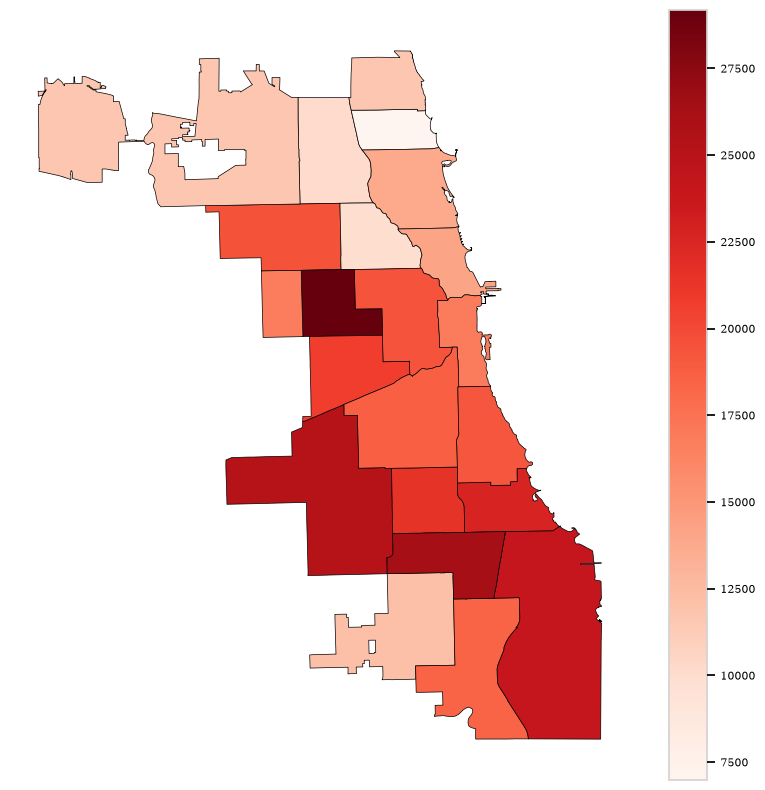

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_districts.plot(
    column='count',
    cmap='Reds',
    linewidth=.5,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.axis('off');

### Heat map of Chicago Average Hardship Index
The hardship index illustrates the spatial distribution of socioeconomic vulnerabiity throughout Chicago. Comparing this map with crime intensity provides preliminary evidence of possible relationships between social conditions and criminal activity.

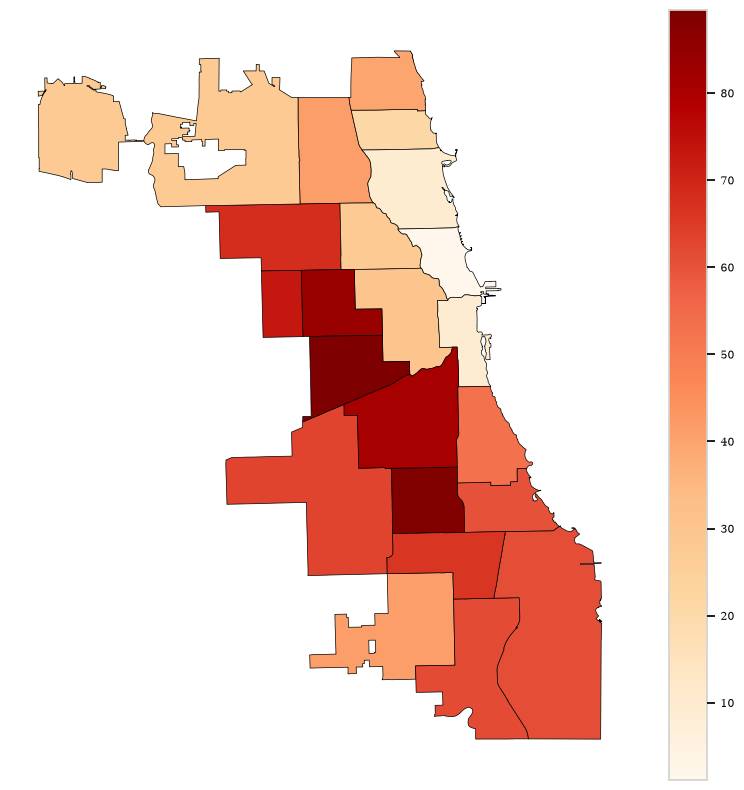

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_districts.plot(
    column='avg_hardship',
    cmap='OrRd',
    linewidth=.5,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.axis('off');

In [16]:
gdf_crimes = gpd.GeoDataFrame(
    df_crime,
    geometry=gpd.points_from_xy(
        df_crime['crime_lat'],
        df_crime['crime_lon']
    ),
    crs='EPSG:4326'
)

gdf_districts_ = gdf_districts.to_crs(3857)
gdf_crimes_ = gdf_crimes.to_crs(3857)

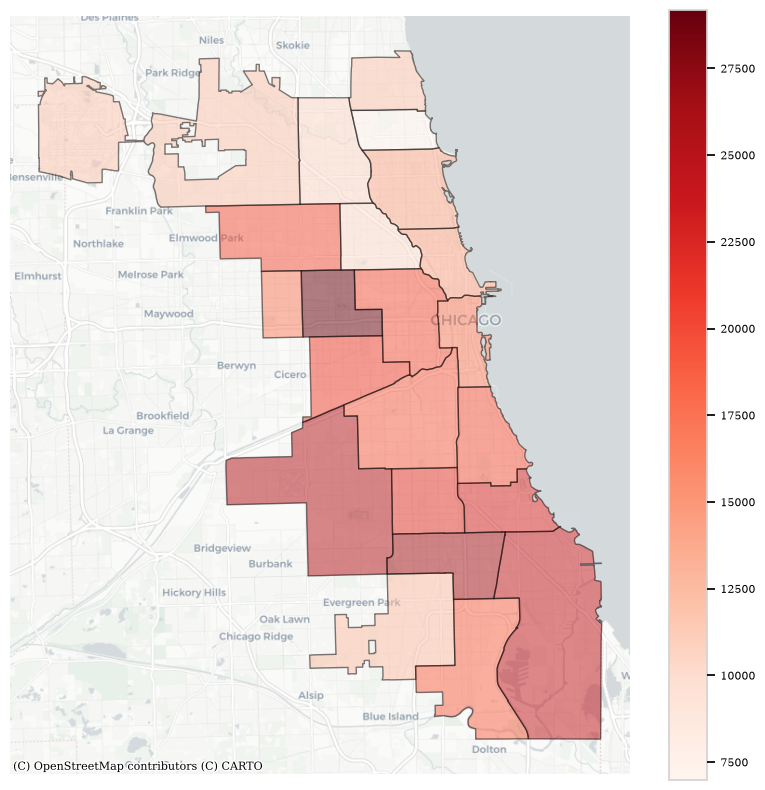

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_districts_.plot(
    column='count',
    cmap='Reds',
    alpha=.5,
    edgecolor='black',
    legend=True,
    ax=ax
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.axis('off');

### Spatial Autocorrelation
We are able to evaluate whether neighboring districts tend to present similar levels of crime activity or whether the observed patterns are randomly distributed across space with spatial autocorrelation analysis. Although we will not assess every variable, we perform it for those we find more valuable results. We do it via global and local Moran's I and Local Indicators of Spatial Association (LISA).

Global Moran's I measures the overall degree of spatial dependence in the data. Positive values indicate that districts with similar crime levels tend to be geographically clustered, while values close to zero suggest spatial randomness.

Local Moran's I, by its turn, extends the global measure by assessing spatial dependence at the district level. It identifies specific areas where local patterns differ from the overall behavior of the city.

Finally, LISA maps classify districts into four spatial associations:

- High-High (HH): high violence surrounded by high violence
- Low-Low (LL): low violence surrounded by low violence
- High-Low (HL): violent districts surrounded by safe neighbors
- Low-High (LH): protected islands inside violent regions

It enables the identification of statistically significant hotspots, cold spots and spatial outliers, providing a detailed view of the geographic organization of crime.

#### ASLT Count

In [ ]:
gdf_count = gdf_districts.copy()

w = Queen.from_dataframe(gdf_count)
w.transform = 'R'

mi = Moran(
    gdf_count['count'],
    w
)

print(mi.I)
print(mi.p_sim)

0.4289682732305787
0.003


/var/folders/8q/r6p05j6x1nb253nlqpbjn42m0000gn/T/ipykernel_1310/3245364165.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_districts)


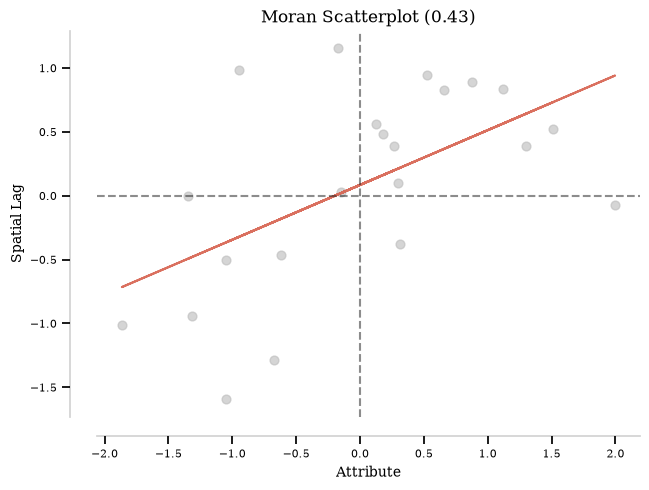

In [19]:
fig, ax = moran_scatterplot(mi)
plt.show()

In [20]:
lisa = Moran_Local(
    gdf_count['count'],
    w
)

gdf_count['lisa_cluster'] = lisa.q
gdf_count['pvalue'] = lisa.p_sim
gdf_count['sig'] = gdf_count['pvalue'] < .05

gdf_count.head()

,the_geom,district,geometry,count,arrest_rate,domestic_rate,avg_hardship,lisa_cluster,pvalue,sig
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",17,"MULTIPOLYGON (((-87.71067 41.99737, -87.71067 ...",10124.0,0.179475,0.297215,41.334058,3,0.002,True
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",20,"MULTIPOLYGON (((-87.66029 41.99092, -87.66029 ...",6985.0,0.190122,0.223622,20.946170,3,0.015,True
4,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",19,"MULTIPOLYGON (((-87.64492 41.96973, -87.64431 ...",13824.0,0.162616,0.167824,9.721427,3,0.001,True
5,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",25,"MULTIPOLYGON (((-87.7174 41.93922, -87.71739 4...",19501.0,0.212451,0.340342,67.934773,4,0.195,False
6,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",14,"MULTIPOLYGON (((-87.69257 41.93943, -87.69253 ...",9977.0,0.190638,0.237446,27.438909,3,0.427,False


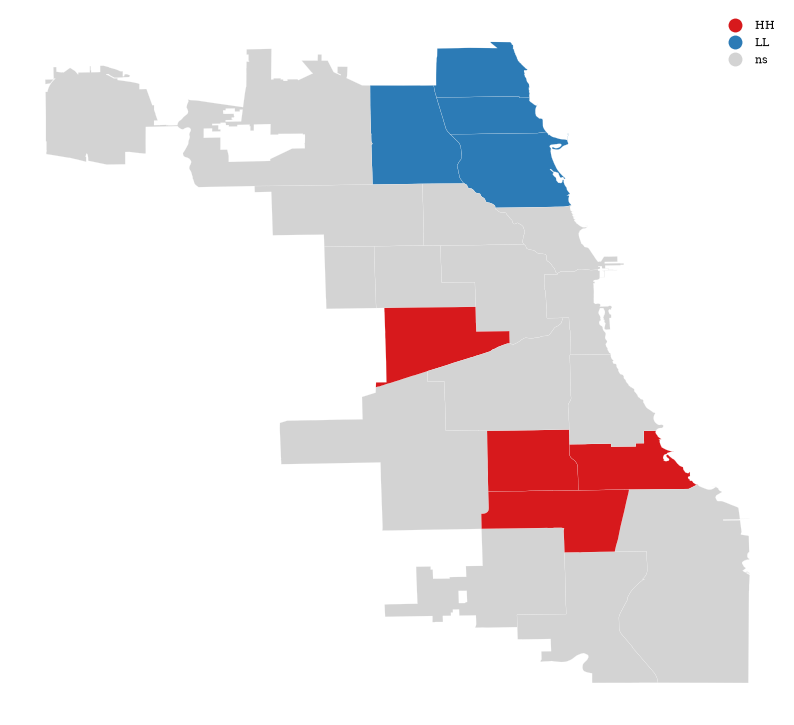

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))

lisa_cluster(
    lisa,
    gdf_count,
    p=.05,
    ax=ax
)

plt.show()

#### Hardship Index

In [22]:
gdf_hardship = gdf_districts.copy()

w = Queen.from_dataframe(gdf_hardship)
w.transform = 'R'

mi = Moran(
    gdf_hardship['avg_hardship'],
    w
)

print(mi.I)
print(mi.p_sim)

0.46918437567971627
0.003


/var/folders/8q/r6p05j6x1nb253nlqpbjn42m0000gn/T/ipykernel_1310/3972623910.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_hardship)


In [23]:
lisa = Moran_Local(
    gdf_hardship['avg_hardship'],
    w
)

gdf_hardship['lisa_cluster'] = lisa.q
gdf_hardship['pvalue'] = lisa.p_sim
gdf_hardship['sig'] = gdf_hardship['pvalue'] < .05

gdf_hardship.head()

,the_geom,district,geometry,count,arrest_rate,domestic_rate,avg_hardship,lisa_cluster,pvalue,sig
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",17,"MULTIPOLYGON (((-87.71067 41.99737, -87.71067 ...",10124.0,0.179475,0.297215,41.334058,3,0.030,True
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",20,"MULTIPOLYGON (((-87.66029 41.99092, -87.66029 ...",6985.0,0.190122,0.223622,20.946170,3,0.075,False
4,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",19,"MULTIPOLYGON (((-87.64492 41.96973, -87.64431 ...",13824.0,0.162616,0.167824,9.721427,3,0.006,True
5,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",25,"MULTIPOLYGON (((-87.7174 41.93922, -87.71739 4...",19501.0,0.212451,0.340342,67.934773,1,0.454,False
6,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",14,"MULTIPOLYGON (((-87.69257 41.93943, -87.69253 ...",9977.0,0.190638,0.237446,27.438909,3,0.111,False


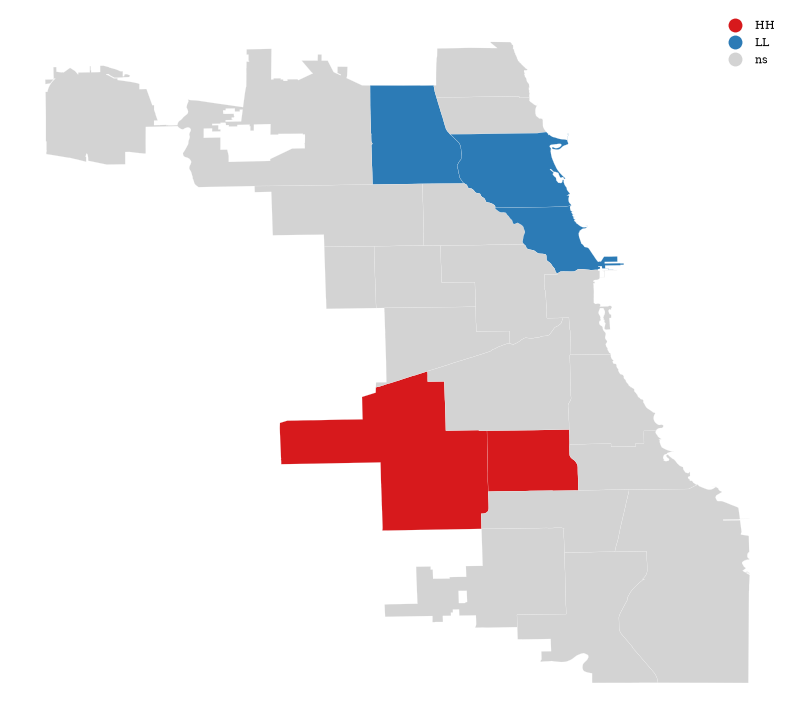

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))

lisa_cluster(
    lisa,
    gdf_hardship,
    p=.05,
    ax=ax
)

plt.show()

## District Characterization

In [98]:
grp_comm_district = pd.read_csv(
    f'{gld_path}/grp_comm_district.csv'
)
grp_comm_district['district'] = grp_comm_district['district'].astype(int).astype(str)

In [129]:
grp_daily_dist = df_crime.query('crime_group == "ASLT"')[[
    'ddate', 'district', 'id'
]].groupby(['ddate', 'district'])\
    .count()\
    .reset_index()

grp_daily_dist = grp_daily_dist.rename(columns={'id': 'count'})

grp_dist = grp_daily_dist.groupby('district')\
    .agg(
        mean=('count', 'mean'),
        std=('count', 'std'),
        min=('count', 'min'),
        max=('count', 'max')
    )

grp_dist['cv'] = grp_dist['mean'] / grp_dist['std']
grp_dist['range'] = grp_dist['max'] - grp_dist['min']

grp_dist = grp_dist.merge(
    grp_comm_district,
    how='left',
    on='district'
)

grp_dist['density'] = grp_dist['mean'] / grp_dist['total_cm_area']

grp_dist.sort_values('density', ascending=False)

,district,mean,std,min,max,cv,range,area_count,avg_cm_area,avg_cm_len,total_cm_area,total_cm_len,avg_housing_crowded,avg_below_pvty,avg_unemployed,avg_without_hsd,avg_dependents,avg_per_capita_income,avg_hardship_index,density
5,15,11.576179,3.849304,2,30,3.007344,28,1,199.254203,75.226475,199.254203,75.226475,0.063000,0.286000,0.226000,0.244000,0.379000,15957.000000,73.000000,0.058098
15,3,15.817130,4.552030,2,34,3.474742,32,6,68.602108,41.011801,411.612648,246.070804,0.033667,0.330833,0.219000,0.175333,0.373833,20014.000000,62.500000,0.038427
10,2,13.441358,4.497751,1,39,2.988462,38,10,41.911249,30.657808,419.112492,306.578082,0.031500,0.349400,0.225900,0.195700,0.376800,21240.700000,64.100000,0.032071
2,11,20.250000,5.344141,1,42,3.789196,41,7,109.321992,47.818497,765.253943,334.729478,0.074571,0.321429,0.176857,0.222429,0.356143,21936.285714,63.571429,0.026462
0,1,11.839382,4.141861,1,30,2.858469,29,7,69.513587,42.997660,486.595108,300.983622,0.036571,0.225000,0.112857,0.160143,0.259571,44906.285714,33.000000,0.024331
13,24,8.113601,3.207963,1,19,2.529206,18,5,67.956005,37.256894,339.780023,186.284470,0.053800,0.166200,0.089600,0.153000,0.308600,28892.800000,30.800000,0.023879
19,7,14.761574,4.368130,2,30,3.379381,28,7,96.077605,44.442936,672.543235,311.100550,0.062286,0.285571,0.231714,0.271714,0.403429,14986.000000,76.142857,0.021949
1,10,14.351852,4.674878,1,33,3.069995,32,6,129.112315,54.400566,774.673892,326.403393,0.074833,0.262667,0.162333,0.294000,0.345500,20979.833333,63.166667,0.018526
18,6,18.134259,5.113585,1,35,3.546290,34,12,85.974150,42.850458,1031.689805,514.205491,0.032500,0.249583,0.216417,0.166833,0.404417,19327.750000,58.916667,0.017577
3,12,13.667438,4.543370,1,32,3.008216,31,10,78.080901,43.799069,780.809008,437.990695,0.053600,0.237800,0.118000,0.189600,0.285200,38318.700000,40.500000,0.017504


## Hopkins

In [38]:
features = pd.read_csv(
    f'{gld_path}/train_aslt.csv',
    index_col='ddate',
    parse_dates=True
).sort_index()

scaler = StandardScaler()
X = scaler.fit_transform(features.drop(columns=['district']))

H = f.hopkins(X)
H

np.float64(0.9606091686095979)

In [39]:
scores = [f.hopkins(X) for _ in range(50)]

print(np.mean(scores))
print(np.std(scores))

0.9609514202227453
0.00030314610294620084


In [41]:
latest_features = features.groupby('district').tail(1)

scaler = StandardScaler()
X = scaler.fit_transform(latest_features.drop(columns=['district']))

scores = [f.hopkins(X) for _ in range(50)]

print(np.mean(scores))
print(np.std(scores))

0.6354170436583175
0.05263364270702687
